## TASK1:Linear Regression with Gradient Descent Variants

In [1]:
#IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
#  Load the dataset 
data = pd.read_csv('census2011.csv')

In [3]:
# 2. Data cleaning and type conversions
# Remove commas from Population, convert to int
data['Population'] = data['Population'].str.replace(',', '').astype(int)
# Remove percentage sign from Growth and convert to float
data['Growth'] = data['Growth'].str.replace('%', '').astype(float)
# Sex-Ratio is int, Literacy is float
data['Sex-Ratio'] = pd.to_numeric(data['Sex-Ratio'], errors='coerce')
data['Literacy'] = pd.to_numeric(data['Literacy'], errors='coerce')

# Drop any rows with missing values (if any)
data = data.dropna()

In [4]:
# 3. Features and target
X = data[['Population', 'Growth', 'Sex-Ratio']].values
y = data['Literacy'].values

In [5]:
# 4. Split data: 70% train, 15% val, 15% test
def train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    train_end = int(train_ratio * len(X))
    val_end = train_end + int(val_ratio * len(X))
    train_idx = idx[:train_end]
    val_idx = idx[train_end:val_end]
    test_idx = idx[val_end:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)


In [6]:
# 5. Feature normalization and bias term addition
def normalize(X, mean=None, std=None):
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
    std_fixed = np.where(std == 0, 1, std)
    return (X - mean) / std_fixed, mean, std_fixed

X_train_norm, mean_train, std_train = normalize(X_train)
X_val_norm, _, _ = normalize(X_val, mean_train, std_train)
X_test_norm, _, _ = normalize(X_test, mean_train, std_train)

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

Xb_train = add_bias(X_train_norm)
Xb_val = add_bias(X_val_norm)
Xb_test = add_bias(X_test_norm)

In [7]:
# 6. Batch Gradient Descent (
def batch_gradient_descent(X, y, lr=0.01, epochs=200):
    n, m = X.shape
    theta = np.zeros(m)
    losses = []
    for epoch in range(epochs):
        preds = X.dot(theta)
        error = preds - y
        grad = (2 / n) * X.T.dot(error)
        theta -= lr * grad
        loss = np.mean(error ** 2)
        losses.append(loss)
    return theta, losses

In [8]:
# 7. Stochastic Gradient Descent (SGD)
def stochastic_gradient_descent(X, y, lr=0.01, epochs=200):
    n, m = X.shape
    theta = np.zeros(m)
    losses = []
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        for i in indices:
            xi = X[i, :].reshape(1, -1)
            yi = y[i]
            pred = xi.dot(theta)
            grad = 2 * xi.T * (pred - yi)
            theta -= lr * grad.flatten()
        preds = X.dot(theta)
        loss = np.mean((preds - y) ** 2)
        losses.append(loss)
    return theta, losses

In [9]:
# 8. Train models with learning rate and epochs
learning_rate = 0.05
epochs = 500

theta_bg, loss_bg = batch_gradient_descent(Xb_train, y_train, lr=learning_rate, epochs=epochs)
theta_sgd, loss_sgd = stochastic_gradient_descent(Xb_train, y_train, lr=learning_rate, epochs=epochs)

In [10]:
# 9. Metrics for evaluation
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

def predict(X, theta):
    return X.dot(theta)

In [11]:
# 10. Evaluate on validation and test sets
for name, theta in [('Batch GD', theta_bg), ('SGD', theta_sgd)]:
    print(f'\n{name} Evaluation on Validation Set:')
    y_val_pred = predict(Xb_val, theta)
    print(f'MSE: {mse(y_val, y_val_pred):.4f}, RMSE: {rmse(y_val, y_val_pred):.4f}, MAE: {mae(y_val, y_val_pred):.4f}, R2: {r2_score(y_val, y_val_pred):.4f}')
    
    print(f'{name} Evaluation on Test Set:')
    y_test_pred = predict(Xb_test, theta)
    print(f'MSE: {mse(y_test, y_test_pred):.4f}, RMSE: {rmse(y_test, y_test_pred):.4f}, MAE: {mae(y_test, y_test_pred):.4f}, R2: {r2_score(y_test, y_test_pred):.4f}')


Batch GD Evaluation on Validation Set:
MSE: 113.7666, RMSE: 10.6661, MAE: 8.3226, R2: -0.0648
Batch GD Evaluation on Test Set:
MSE: 91.3075, RMSE: 9.5555, MAE: 7.8294, R2: 0.0860

SGD Evaluation on Validation Set:
MSE: 338.6977, RMSE: 18.4037, MAE: 12.0736, R2: -2.1700
SGD Evaluation on Test Set:
MSE: 143.5799, RMSE: 11.9825, MAE: 8.5730, R2: -0.4372


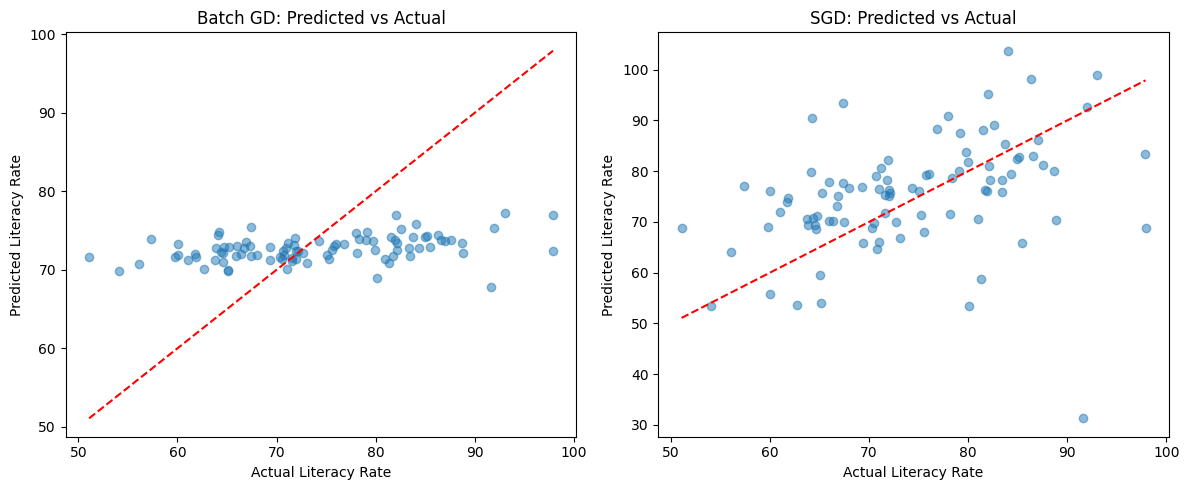

In [12]:
# 11. Plots: predicted vs actual
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, predict(Xb_test, theta_bg), alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Batch GD: Predicted vs Actual')
plt.xlabel('Actual Literacy Rate')
plt.ylabel('Predicted Literacy Rate')

plt.subplot(1, 2, 2)
plt.scatter(y_test, predict(Xb_test, theta_sgd), alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('SGD: Predicted vs Actual')
plt.xlabel('Actual Literacy Rate')
plt.ylabel('Predicted Literacy Rate')
plt.tight_layout()
plt.show()

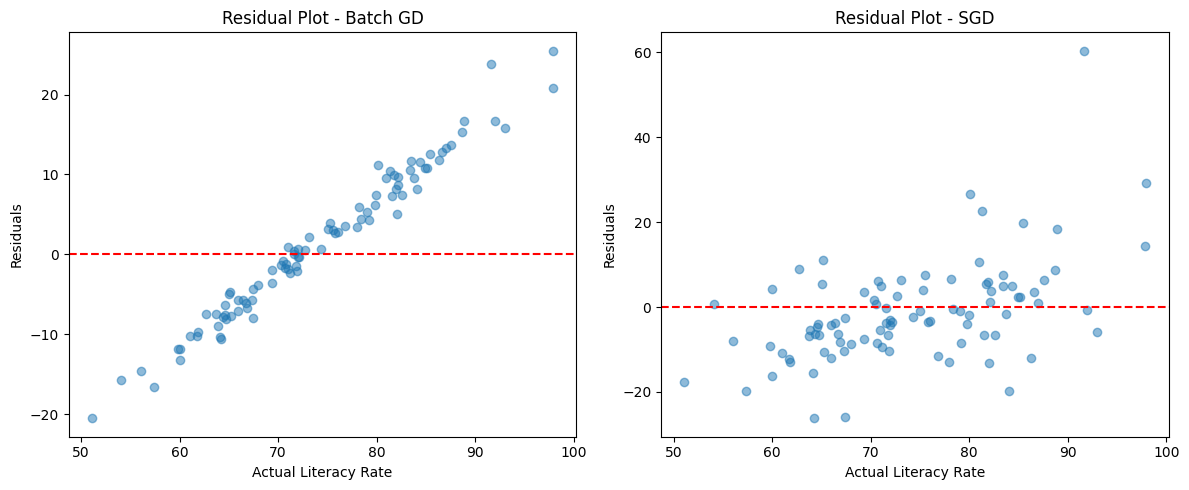

In [13]:

# 12. Residual plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test - predict(Xb_test, theta_bg), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot - Batch GD')
plt.xlabel('Actual Literacy Rate')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test - predict(Xb_test, theta_sgd), alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot - SGD')
plt.xlabel('Actual Literacy Rate')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()


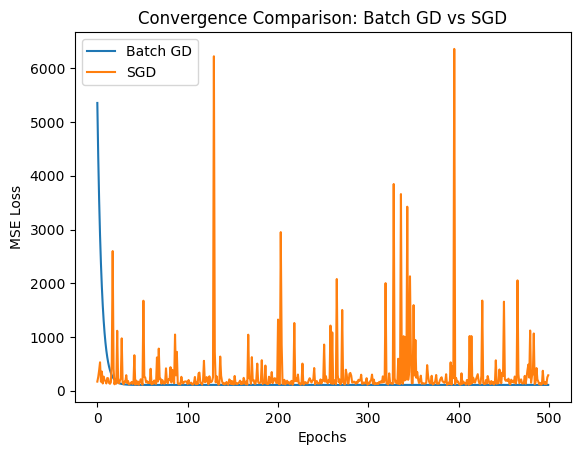

In [14]:
# 13. Convergence plot: loss vs epochs for both methods
plt.plot(loss_bg, label='Batch GD')
plt.plot(loss_sgd, label='SGD')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Convergence Comparison: Batch GD vs SGD')
plt.legend()
plt.show()

## TASK2:KNN CLASSIFIER

In [19]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [20]:
# 1. Load and clean data
data = pd.read_csv('census2011.csv')
data['Population'] = data['Population'].str.replace(',', '').astype(int)
data['Growth'] = data['Growth'].str.replace('%', '').astype(float)
data['Sex-Ratio'] = pd.to_numeric(data['Sex-Ratio'], errors='coerce')
data['Literacy'] = pd.to_numeric(data['Literacy'], errors='coerce')
data = data.dropna()

In [21]:
# 2. Categorize Literacy into classes (Low<65, Medium 65-85, High>85)
def categorize_literacy(lit):
    if lit < 65:
        return 0  # Low
    elif lit <= 85:
        return 1  # Medium
    else:
        return 2  # High

y_class = np.array([categorize_literacy(val) for val in data['Literacy']])

In [22]:
# 4. Shuffle split into train/val/test (70%, 15%, 15%)
def train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    train_end = int(train_ratio * len(X))
    val_end = train_end + int(val_ratio * len(X))
    train_idx, val_idx, test_idx = indices[:train_end], indices[train_end:val_end], indices[val_end:]
    
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y_class)

In [23]:
# 5. Normalize features
def normalize(X, mean=None, std=None):
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
    std_fixed = np.where(std == 0, 1, std)
    return (X - mean) / std_fixed, mean, std_fixed

X_train_norm, mean_train, std_train = normalize(X_train)
X_val_norm, _, _ = normalize(X_val, mean_train, std_train)
X_test_norm, _, _ = normalize(X_test, mean_train, std_train)

In [24]:
# 6. Euclidean distance helper
def euclidean_dist(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))

In [26]:
# 7. KNN Classifier from scratch
def knn_predict(X_train, y_train, X_test, k):
    preds = []
    for x in X_test:
        distances = euclidean_dist(X_train, x)
        k_nearest_idx = np.argsort(distances)[:k]
        k_nearest_labels = y_train[k_nearest_idx]
        votes = np.bincount(k_nearest_labels)
        preds.append(np.argmax(votes))
    return np.array(preds)

In [27]:
# 8. Accuracy calculation
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [28]:
for k in [3, 5, 7]:
    y_pred = knn_predict(X_train_norm, y_train, X_test_norm, k)
    print(f"KNN Accuracy on Test Set for k={k}: {accuracy(y_test, y_pred):.3f}")

KNN Accuracy on Test Set for k=3: 0.565
KNN Accuracy on Test Set for k=5: 0.576
KNN Accuracy on Test Set for k=7: 0.609


In [29]:
# 9. Confusion matrix (manual implementation)
def confusion_matrix_manual(y_true, y_pred, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for a, p in zip(y_true, y_pred):
        cm[a, p] += 1
    return cm

best_k = 5
y_pred_best = knn_predict(X_train_norm, y_train, X_test_norm, best_k)
cm = confusion_matrix_manual(y_test, y_pred_best)

<ipython-input-30-338463f9a7b9>:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels)
<ipython-input-30-338463f9a7b9>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels)


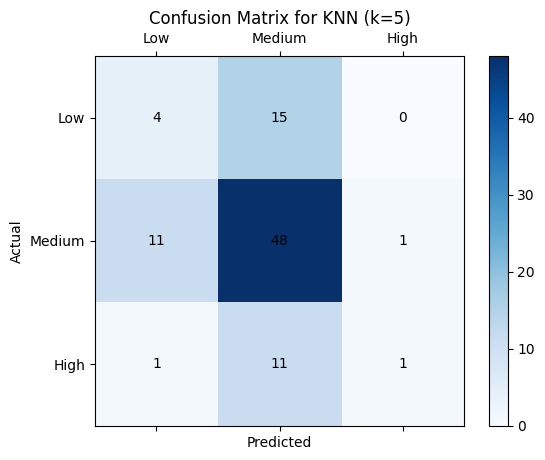

In [30]:
# 10. Plot confusion matrix with matplotlib
def plot_confusion_matrix(cm, labels):
    fig, ax = plt.subplots()
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)
    ax.set_xticklabels([''] + labels)
    ax.set_yticklabels([''] + labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for KNN (k={best_k})')

    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center')

    plt.show()

labels = ['Low', 'Medium', 'High']
plot_confusion_matrix(cm, labels)